TUGAS FISIKA KOMPUTASI LANJUT 12\
Ardiansah Nur Rohman\
230322607922

Tugas 1

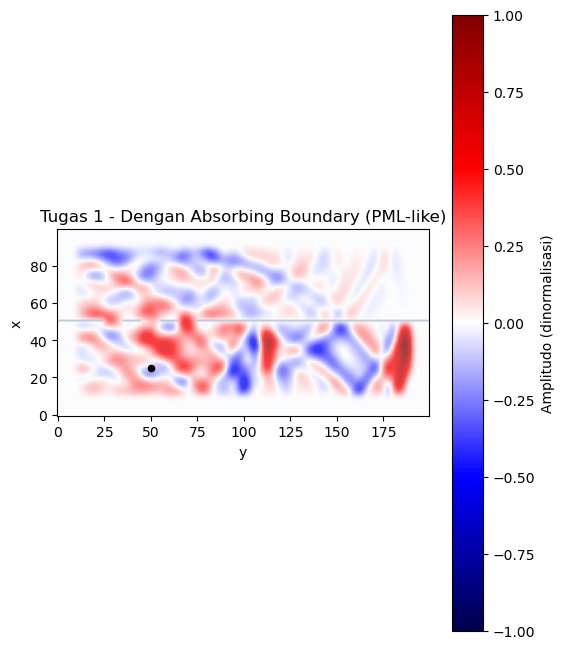

In [1]:
# tugas1_pml.py
# Simulasi Gelombang 2D (Tugas 1) dengan absorbing boundary (PML-like damping)
# Domain: 100 x 200, tiga celah lebar 10 di x=50 (y=30,50,70), sumber di (25,50)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------- Parameters ----------------
nx, ny = 100, 200
dx = dy = 1.0
dt = 0.30               # aman untuk c up to 2.0
c = 1.0                 # kecepatan utama (tugas 1 memakai c=1)
steps = 500

# ---------------- Inisialisasi ----------------
u = np.zeros((nx, ny))
u_prev = np.zeros((nx, ny))
u_next = np.zeros((nx, ny))

# sumber Gaussian di (25,50)
x0, y0 = 25, 50
sigma = 3.0
X = np.arange(nx)[:, None]
Y = np.arange(ny)[None, :]
gaussian = np.exp(-(((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)))
u = gaussian.copy()
u_prev = gaussian.copy()

# ---------------- Barrier + celah ----------------
mask = np.ones((nx, ny), dtype=bool)
barrier_x = 50
gap_centers = [30, 50, 70]
gap_width = 10
mask[barrier_x, :] = False
for yc in gap_centers:
    start = max(0, int(yc - gap_width//2))
    end = min(ny, int(yc + gap_width//2))
    mask[barrier_x, start:end] = True

# overlay barrier visual
overlay = np.zeros((nx, ny))
overlay[barrier_x, :] = 1.0
for yc in gap_centers:
    start = max(0, int(yc - gap_width//2))
    end = min(ny, int(yc + gap_width//2))
    overlay[barrier_x, start:end] = 0.0

# ---------------- Absorbing boundary (PML-like) ----------------
# Buat damping profile (0 di dalam domain, meningkat ke pinggir)
pml_width = 12             # lebar PML di setiap sisi (grid points)
sigma_max = 2.5            # kuatnya redaman maksimum (adjustable)

# distance ke tepi (0 at interior center, up to pml_width at edge of PML)
sigma = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        di = 0
        dj = 0
        # jarak ke tepi mendatar (x)
        if i < pml_width:
            di = (pml_width - i) / pml_width
        elif i >= nx - pml_width:
            di = (i - (nx - pml_width - 1)) / pml_width
        # jarak ke tepi vertikal (y)
        if j < pml_width:
            dj = (pml_width - j) / pml_width
        elif j >= ny - pml_width:
            dj = (j - (ny - pml_width - 1)) / pml_width
        r = max(di, dj)    # gunakan maksimum (corner lebih kuat)
        sigma[i, j] = (r**2) * sigma_max

# faktor pengali per langkah waktu (eksponensial redaman)
damping_factor = np.exp(-sigma * dt)

# ---------------- Time stepping (explicit) ----------------
def step_time():
    global u, u_prev, u_next
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            if not mask[i, j]:
                u_next[i, j] = 0.0
                continue
            lap = (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / dx**2
            u_next[i, j] = 2*u[i,j] - u_prev[i,j] + (c * dt)**2 * lap
            # apply local damping (PML)
            u_next[i, j] *= damping_factor[i, j]

    # Dirichlet boundary (tepi = 0)
    u_next[0,:] = 0.0
    u_next[-1,:] = 0.0
    u_next[:,0] = 0.0
    u_next[:,-1] = 0.0

    u_prev, u = u, u_next.copy()

# ---------------- Visualisasi ----------------
fig, ax = plt.subplots(figsize=(6, 8))
im_wave = ax.imshow(u, cmap='seismic', vmin=-1, vmax=1, origin='lower')
im_barrier = ax.imshow(overlay, cmap='Blues', alpha=0.25, origin='lower')
ax.scatter(y0, x0, color='k', s=20)
ax.set_title('Tugas 1 - Dengan Absorbing Boundary (PML-like)')
ax.set_xlabel('y'); ax.set_ylabel('x')
cbar = fig.colorbar(im_wave, ax=ax); cbar.set_label('Amplitudo (dinormalisasi)')

def update(frame):
    step_time()
    maxv = np.max(np.abs(u))
    display = u / maxv if maxv != 0 else u
    im_wave.set_array(display)
    im_barrier.set_array(overlay)
    return [im_wave, im_barrier]

ani = animation.FuncAnimation(fig, update, frames=steps, interval=30, blit=True)

# simpan jika mau (aktifkan)
ani.save("tugas1_pml.mp4", writer='ffmpeg', fps=30)

plt.show()


Tugas 2

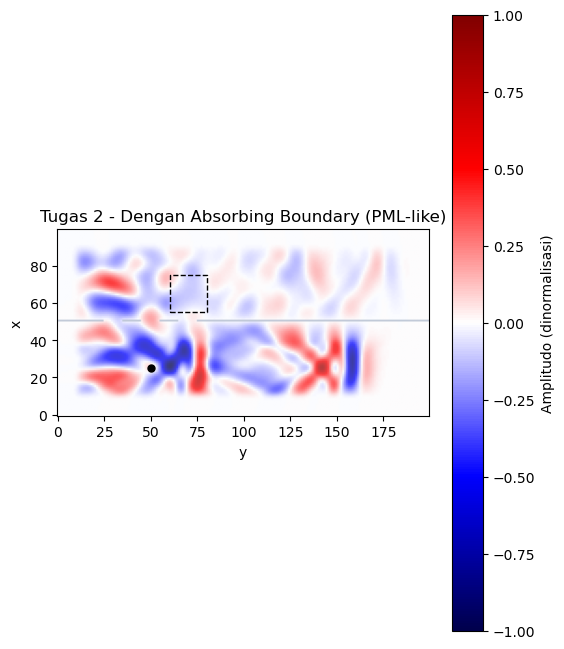

In [2]:
# tugas2_pml.py
# Simulasi Gelombang 2D (Tugas 2) dengan absorbing boundary (PML-like)
# Domain: 100 x 200, celah di x=50, sumber di (25,50)
# Material: top c=0.75, bottom c=1.0, inclusion c=2.0

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---------------- Params ----------------
nx, ny = 100, 200
dx = dy = 1.0
dt = 0.30
steps = 500

# ---------------- Arrays ----------------
u = np.zeros((nx, ny))
u_prev = np.zeros((nx, ny))
u_next = np.zeros((nx, ny))

# source
x0, y0 = 25, 50
sigma = 3.0
X = np.arange(nx)[:, None]
Y = np.arange(ny)[None, :]
gaussian = np.exp(-(((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)))
u = gaussian.copy()
u_prev = gaussian.copy()

# ---------------- Barrier with gaps ----------------
mask = np.ones((nx, ny), dtype=bool)
barrier_x = 50
gap_centers = [30, 50, 70]
gap_width = 10
mask[barrier_x, :] = False
for yc in gap_centers:
    start = max(0, int(yc - gap_width//2))
    end = min(ny, int(yc + gap_width//2))
    mask[barrier_x, start:end] = True

overlay = np.zeros((nx, ny))
overlay[barrier_x, :] = 1.0
for yc in gap_centers:
    start = max(0, int(yc - gap_width//2))
    end = min(ny, int(yc + gap_width//2))
    overlay[barrier_x, start:end] = 0.0

# ---------------- c_map (material) ----------------
c_map = np.ones((nx, ny)) * 0.75   # default top (we will set bottom below)
c_map[40:, :] = 1.0                # bottom region x >= 40 -> c=1.0

# inclusion: rectangle c=2.0 (sesuaikan jika mau posisi lain)
inc_x_start, inc_x_end = 55, 75   # x indices (vertically)
inc_y_start, inc_y_end = 60, 80   # y indices (horizontally)
c_map[inc_x_start:inc_x_end, inc_y_start:inc_y_end] = 2.0

# cek c_max vs CFL (pastikan dt sesuai)
c_max = np.max(c_map)
if c_max * dt / dx >= 1/np.sqrt(2):
    raise RuntimeError(f"CFL not satisfied (c_max*dt/dx = {c_max*dt/dx:.3f}). Reduce dt or increase dx.")

# ---------------- PML-like absorbing layer ----------------
pml_width = 12
sigma_max = 2.5
sigma = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        di = 0
        dj = 0
        if i < pml_width:
            di = (pml_width - i) / pml_width
        elif i >= nx - pml_width:
            di = (i - (nx - pml_width - 1)) / pml_width
        if j < pml_width:
            dj = (pml_width - j) / pml_width
        elif j >= ny - pml_width:
            dj = (j - (ny - pml_width - 1)) / pml_width
        r = max(di, dj)
        sigma[i, j] = (r**2) * sigma_max
damping_factor = np.exp(-sigma * dt)

# ---------------- Time stepping ----------------
def step_time():
    global u, u_prev, u_next
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            if not mask[i, j]:
                u_next[i, j] = 0.0
                continue
            lap = (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / dx**2
            cc = c_map[i, j]
            u_next[i, j] = 2*u[i, j] - u_prev[i, j] + (cc * dt)**2 * lap
            u_next[i, j] *= damping_factor[i, j]
    u_next[0,:] = 0.0; u_next[-1,:] = 0.0; u_next[:,0] = 0.0; u_next[:,-1] = 0.0
    u_prev, u = u, u_next.copy()

# ---------------- Visualisasi ----------------
fig, ax = plt.subplots(figsize=(6, 8))
im_wave = ax.imshow(u, cmap='seismic', vmin=-1, vmax=1, origin='lower')
im_barrier = ax.imshow(overlay, cmap='Blues', alpha=0.25, origin='lower')
ax.scatter(y0, x0, color='k', s=25)
ax.set_title('Tugas 2 - Dengan Absorbing Boundary (PML-like)')
ax.set_xlabel('y'); ax.set_ylabel('x')
cbar = fig.colorbar(im_wave, ax=ax); cbar.set_label('Amplitudo (dinormalisasi)')

# gambar kotak inclusion (visual helper)
rect_x = [inc_y_start, inc_y_end, inc_y_end, inc_y_start, inc_y_start]
rect_y = [inc_x_start, inc_x_start, inc_x_end, inc_x_end, inc_x_start]
ax.plot(rect_x, rect_y, linestyle='--', color='k', linewidth=1)

def update(frame):
    step_time()
    maxv = np.max(np.abs(u))
    display = u / maxv if maxv != 0 else u
    im_wave.set_array(display)
    im_barrier.set_array(overlay)
    return [im_wave, im_barrier]

ani = animation.FuncAnimation(fig, update, frames=steps, interval=30, blit=True)

# simpan jika perlu
ani.save("tugas2_pml.mp4", writer='ffmpeg', fps=30)

plt.show()
